# Projeto Av3 - Consumo de Energia por Bairros

Projeto com notebook que usa K-Means para agrupar 20 bairros conforme o perfil de consumo de energia.

(Dados simulados)

## 1. Importar bibliotecas

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## 2. Ler a base de dados

In [2]:
dados = pd.read_csv("consumo_energia.csv")
print("Total de bairros:", len(dados))
dados.head()

Total de bairros: 20


,bairro,num_unidades_consumidoras,consumo_medio_kwh,consumo_total_kwh,perda_estimada_pct
0,Suburbio,25000,150,3750000,16.2
1,Cajazeiras,30000,140,4200000,17.8
2,Sao Caetano,20000,160,3200000,15.4
3,Liberdade,22000,155,3410000,16.9
4,Periperi,19000,135,2565000,18.5


## 3. Escolher as colunas usadas pelo K-Means

Para deixar a explicação mais simples, o agrupamento usa:
- consumo médio em kWh;
- perda estimada em porcentagem.

In [3]:
colunas_usadas = [
    "consumo_medio_kwh",
    "perda_estimada_pct"
]

x = dados[colunas_usadas]
x.head()

,consumo_medio_kwh,perda_estimada_pct
0,150,16.2
1,140,17.8
2,160,15.4
3,155,16.9
4,135,18.5


## 4. Padronizar os dados

In [4]:
padronizador = StandardScaler()
x_padronizado = padronizador.fit_transform(x)

## 5. Aplicar o K-Means

In [5]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
dados["cluster"] = kmeans.fit_predict(x_padronizado)
dados.head()

,bairro,num_unidades_consumidoras,consumo_medio_kwh,consumo_total_kwh,perda_estimada_pct,cluster
0,Suburbio,25000,150,3750000,16.2,2
1,Cajazeiras,30000,140,4200000,17.8,2
2,Sao Caetano,20000,160,3200000,15.4,2
3,Liberdade,22000,155,3410000,16.9,2
4,Periperi,19000,135,2565000,18.5,2


## 6. Nomear os grupos

In [6]:
media_por_cluster = dados.groupby("cluster")["consumo_medio_kwh"].mean().sort_values()

nomes_dos_grupos = [
    "Baixo consumo",
    "Consumo medio",
    "Alto consumo",
    "Grande consumidor"
]

mapa_nomes = {}

for numero_cluster, nome in zip(media_por_cluster.index, nomes_dos_grupos):
    mapa_nomes[numero_cluster] = nome

dados["tipo_consumo"] = dados["cluster"].map(mapa_nomes)
dados[["bairro", "consumo_medio_kwh", "perda_estimada_pct", "tipo_consumo"]]

,bairro,consumo_medio_kwh,perda_estimada_pct,tipo_consumo
0,Suburbio,150,16.2,Baixo consumo
1,Cajazeiras,140,17.8,Baixo consumo
2,Sao Caetano,160,15.4,Baixo consumo
3,Liberdade,155,16.9,Baixo consumo
4,Periperi,135,18.5,Baixo consumo
5,Paripe,145,17.2,Baixo consumo
6,Brotas,310,10.8,Consumo medio
7,Itapua,290,11.5,Consumo medio
8,Cabula,270,12.1,Consumo medio
9,Federacao,300,10.4,Consumo medio


## 7. Ver os bairros de cada tipo de consumo

In [7]:
ordem = [
    "Baixo consumo",
    "Consumo medio",
    "Alto consumo",
    "Grande consumidor"
]

for tipo in ordem:
    print("\n" + tipo.upper())
    bairros = dados[dados["tipo_consumo"] == tipo]["bairro"].tolist()

    for bairro in bairros:
        print("- " + bairro)


BAIXO CONSUMO
- Suburbio
- Cajazeiras
- Sao Caetano
- Liberdade
- Periperi
- Paripe

CONSUMO MEDIO
- Brotas
- Itapua
- Cabula
- Federacao
- Rio Vermelho

ALTO CONSUMO
- Barra
- Pituba
- Caminho das Arvores
- Graca
- Horto Florestal
- Ondina

GRANDE CONSUMIDOR
- CIA - Polo Industrial
- Comercio
- Aeroporto


## 8. Tabela final dos bairros classificados

In [8]:
tabela_final = dados.sort_values(["tipo_consumo", "bairro"])[
    [
        "bairro",
        "num_unidades_consumidoras",
        "consumo_medio_kwh",
        "perda_estimada_pct",
        "tipo_consumo"
    ]
]

tabela_final

,bairro,num_unidades_consumidoras,consumo_medio_kwh,perda_estimada_pct,tipo_consumo
11,Barra,12000,480,6.7,Alto consumo
13,Caminho das Arvores,9000,530,5.4,Alto consumo
14,Graca,7000,470,6.3,Alto consumo
15,Horto Florestal,6000,560,4.8,Alto consumo
16,Ondina,7500,490,6.1,Alto consumo
12,Pituba,15000,510,5.9,Alto consumo
1,Cajazeiras,30000,140,17.8,Baixo consumo
3,Liberdade,22000,155,16.9,Baixo consumo
5,Paripe,21000,145,17.2,Baixo consumo
4,Periperi,19000,135,18.5,Baixo consumo


## 9. Gráfico dos clusters

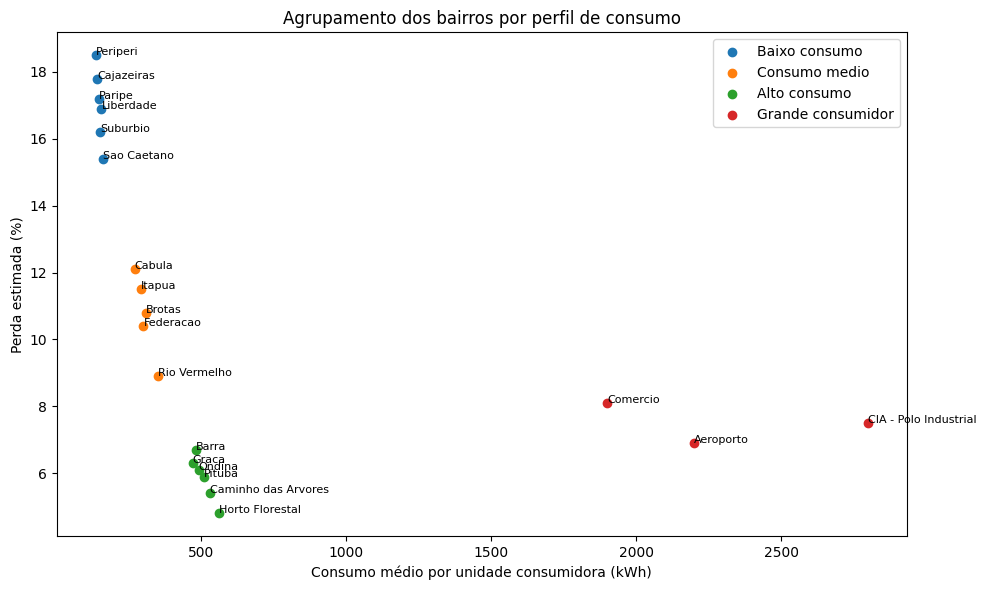

In [9]:
plt.figure(figsize=(10, 6))

for tipo in ordem:
    grupo = dados[dados["tipo_consumo"] == tipo]

    plt.scatter(
        grupo["consumo_medio_kwh"],
        grupo["perda_estimada_pct"],
        label=tipo
    )

    for _, linha in grupo.iterrows():
        plt.text(
            linha["consumo_medio_kwh"],
            linha["perda_estimada_pct"],
            linha["bairro"],
            fontsize=8
        )

plt.title("Agrupamento dos bairros por perfil de consumo")
plt.xlabel("Consumo médio por unidade consumidora (kWh)")
plt.ylabel("Perda estimada (%)")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Quantidade de bairros por tipo de consumo

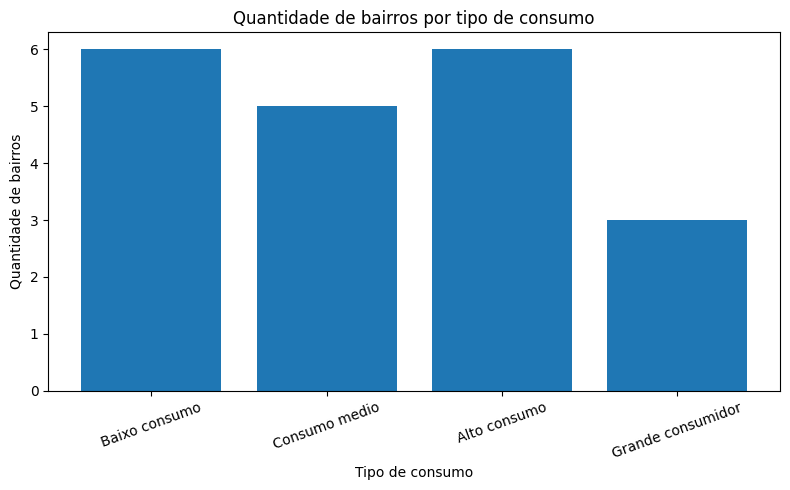

In [10]:
contagem = dados["tipo_consumo"].value_counts().reindex(ordem)

plt.figure(figsize=(8, 5))
plt.bar(contagem.index, contagem.values)
plt.title("Quantidade de bairros por tipo de consumo")
plt.xlabel("Tipo de consumo")
plt.ylabel("Quantidade de bairros")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 11. Salvar resultados

In [11]:
dados.to_csv("resultado_clusters.csv", index=False, encoding="utf-8")

resumo = (
    dados.sort_values("bairro")
    .groupby("tipo_consumo")["bairro"]
    .apply(lambda lista: ", ".join(lista))
    .reset_index()
)

resumo["quantidade_bairros"] = resumo["bairro"].apply(lambda texto: len(texto.split(", ")))
resumo.to_csv("bairros_por_tipo_consumo.csv", index=False, encoding="utf-8")

print("Arquivos salvos com sucesso.")

Arquivos salvos com sucesso.
